# Mini-Batch Gradient Descent 

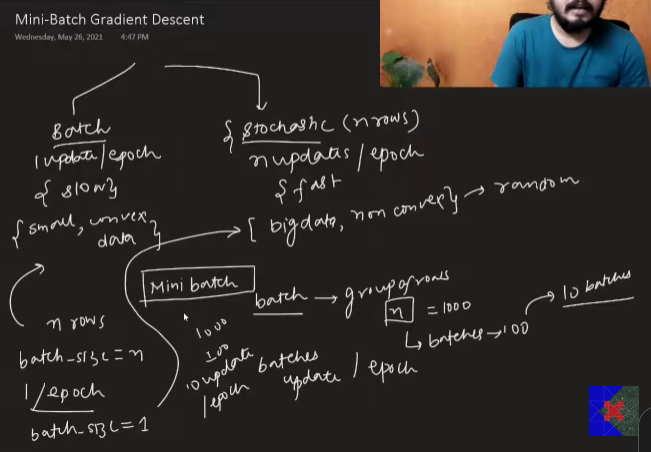

- It's in between batch and stochastic gradient descent. It splits the training data into small batches and performs an update for each batch.

- This helps in reducing the randomness that we faced in stochastic gradient descent and also helps in faster convergence than batch gradient descent.

- Like if no.  of rows = $n$
    Then, for bath size = $b$, no. of batches = $\frac{n}{b}$

    - For b = n, we get batch gradient descent
    - For b = 1, we get stochastic gradient descent

    (So its kind of a generalization of both batch and stochastic gradient descent)

In [1]:
from sklearn.datasets import load_diabetes

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [2]:
X,y = load_diabetes(return_X_y=True)

In [3]:
print(X.shape)
print(y.shape)

(442, 10)
(442,)


In [4]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [5]:
reg = LinearRegression()
reg.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
print(reg.coef_)
print(reg.intercept_)

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
151.88331005254167


In [7]:
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.439933866156897

In [ ]:
import random

random.sample(range(10),5) # it doesnt guarantee that unique numbers will be generated

[9, 6, 1, 3, 7]

In [21]:
idx = random.sample(range(X_train.shape[0]),5)
X_train[idx] # this will give us 5 random samples from the training data based on the index generated by random.sample() function.

array([[-0.01641217, -0.04464164,  0.05415152,  0.0700723 , -0.03321588,
        -0.0279315 ,  0.00814208, -0.03949338, -0.02712902, -0.00936191],
       [-0.00914709, -0.04464164,  0.01103904, -0.05731319, -0.02496016,
        -0.04296262,  0.03023191, -0.03949338,  0.01703607, -0.0052198 ],
       [-0.07090025, -0.04464164,  0.03906215, -0.03321323, -0.01257658,
        -0.03450761, -0.02499266, -0.00259226,  0.06773705, -0.01350402],
       [-0.04547248,  0.05068012, -0.04716281, -0.01599898, -0.04009564,
        -0.02480001,  0.00077881, -0.03949338, -0.06291688, -0.03835666],
       [-0.02004471, -0.04464164, -0.046085  , -0.0986274 , -0.07587041,
        -0.05987264, -0.01762938, -0.03949338, -0.05140387, -0.04664087]])

In [22]:
import random

class MBGDRegressor:
    
    def __init__(self,batch_size,learning_rate=0.01,epochs=100):
        
        self.coef_ = None
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        
    def fit(self,X_train,y_train):
        # init your coefs
        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])
        
        for i in range(self.epochs):
            
            for j in range(int(X_train.shape[0]/self.batch_size)):
                
                idx = random.sample(range(X_train.shape[0]),self.batch_size) # generate random batch indices
                
                y_hat = np.dot(X_train[idx],self.coef_) + self.intercept_
                print("Shape of y_hat",y_hat.shape)

                intercept_der = -2 * np.mean(y_train[idx] - y_hat)
                self.intercept_ = self.intercept_ - (self.lr * intercept_der)

                coef_der = -2 * np.dot((y_train[idx] - y_hat),X_train[idx])
                self.coef_ = self.coef_ - (self.lr * coef_der)
        
        print(self.intercept_,self.coef_)
    
    def predict(self,X_test):
        return np.dot(X_test,self.coef_) + self.intercept_

In [23]:
mbr = MBGDRegressor(batch_size=int(X_train.shape[0]/50),learning_rate=0.01,epochs=100)

In [24]:
mbr.fit(X_train,y_train)

Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)
Shape of y_hat (7,)


In [11]:
y_pred = mbr.predict(X_test)

In [12]:
r2_score(y_test,y_pred)

0.45096094183053326

# Implementing mini-batch gradient descent using SGDRegressor class of sklearn

- Humare paas direct koi parameter nhi hai in SGDRegressor class me jisse hum mini-batch gradient descent ko implement kar sake. But we can use the `partial_fit` method of this class to achieve mini-batch gradient descent.

In [13]:
from sklearn.linear_model import SGDRegressor

In [14]:
sgd = SGDRegressor(learning_rate='constant',eta0=0.1)

In [15]:
batch_size = 35

for i in range(100):
    
    idx = random.sample(range(X_train.shape[0]),batch_size)
    sgd.partial_fit(X_train[idx],y_train[idx])

In [16]:
sgd.coef_

array([  45.01468102,  -56.42715799,  336.06165941,  224.94033439,
         34.98274103,   -1.26092715, -172.33490079,  139.84261881,
        300.55512481,  126.86139535])

In [17]:
sgd.intercept_

array([146.24719313])

In [18]:
y_pred = sgd.predict(X_test)

In [19]:
r2_score(y_test,y_pred)

0.42153787573074775

# Visualization of mini-batch gradient descent 

- See the contour plot below. It is kind of in between batch and stochastic gradient descent. It is not as smooth as batch gradient descent but also not as random as stochastic gradient descent.

- The same problem is there that it fluctuates around the minimum. So to solve it we can do **learning rate scheduling**. We can start with a higher learning rate and then gradually decrease it as we get closer to the minimum.

![mbd-contour-plot-animation.gif](./mini_batch_contour_plot.gif)

- Below is SGD contour plot for reference:

![Batch-contour-plot-animation.gif](../D51-Gradient-descent/animations/animation8.gif)

- Below is SGD contour plot for reference:

![Sgd-contour-plot-animation.gif](../D52-Types-of-gradient-descent/stochastic_animation_contour_plot2.gif)